In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv(r"C:\Users\Lala\Downloads\archive\ab_data.csv")

In [3]:
df

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1
...,...,...,...,...,...
294473,751197,2017-01-03 22:28:38.630509,control,old_page,0
294474,945152,2017-01-12 00:51:57.078372,control,old_page,0
294475,734608,2017-01-22 11:45:03.439544,control,old_page,0
294476,697314,2017-01-15 01:20:28.957438,control,old_page,0


In [5]:
df.shape

(294478, 5)

## Group size

In [6]:
df['group'].value_counts()

group
treatment    147276
control      147202
Name: count, dtype: int64

## Group uzre conversion rate

In [8]:
df.groupby('group')['converted'].mean()

group
control      0.120399
treatment    0.118920
Name: converted, dtype: float64

## Misasigned users

In [9]:
misassigned = (
    ((df["group"] == "treatment") & (df["landing_page"] == "old_page")) |
    ((df["group"] == "control") & (df["landing_page"] == "new_page")))

In [10]:
misassigned.sum()

np.int64(3893)

In [15]:
df_clean = df[~misassigned].copy()

In [16]:
df_clean

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1
...,...,...,...,...,...
294473,751197,2017-01-03 22:28:38.630509,control,old_page,0
294474,945152,2017-01-12 00:51:57.078372,control,old_page,0
294475,734608,2017-01-22 11:45:03.439544,control,old_page,0
294476,697314,2017-01-15 01:20:28.957438,control,old_page,0


##  Conversion rate for control and treatment groups

In [17]:
conversion_rates = df_clean.groupby("group")["converted"].mean() * 100

In [19]:
conversion_rates.round(2)

group
control      12.04
treatment    11.88
Name: converted, dtype: float64

## The absolute and relative difference in conversion rate


In [20]:
control_rate= conversion_rates['control']

In [22]:
treatment_rate=conversion_rates['treatment']

In [29]:
absolute_difference= treatment_rate - control_rate

In [35]:
relative_difference= (absolute_difference /control_rate)*100

In [31]:
absolute_difference.round(2)

np.float64(-0.16)

In [36]:
relative_difference.round(2)

np.float64(-1.31)

## Günlər üzrə conversion rate analizi

In [37]:
df_clean['timestamp']=pd.to_datetime(df_clean['timestamp'])

In [38]:
df_clean['date']=df_clean['timestamp'].dt.date

In [39]:
df_clean

,user_id,timestamp,group,landing_page,converted,date
0,851104,2017-01-21 22:11:48.556739,control,old_page,0,2017-01-21
1,804228,2017-01-12 08:01:45.159739,control,old_page,0,2017-01-12
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0,2017-01-11
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0,2017-01-08
4,864975,2017-01-21 01:52:26.210827,control,old_page,1,2017-01-21
...,...,...,...,...,...,...
294473,751197,2017-01-03 22:28:38.630509,control,old_page,0,2017-01-03
294474,945152,2017-01-12 00:51:57.078372,control,old_page,0,2017-01-12
294475,734608,2017-01-22 11:45:03.439544,control,old_page,0,2017-01-22
294476,697314,2017-01-15 01:20:28.957438,control,old_page,0,2017-01-15


In [40]:
daily_conversion = (df_clean.groupby(["date", "group"]).agg(
        users=("user_id", "count"),
        conversions=("converted", "sum")).reset_index())

In [42]:
daily_conversion.head(5)

,date,group,users,conversions
0,2017-01-02,control,2859,359
1,2017-01-02,treatment,2853,342
2,2017-01-03,control,6590,750
3,2017-01-03,treatment,6618,753
4,2017-01-04,control,6578,802


In [47]:
daily_conversion["conversion_rate"] = ((daily_conversion["conversions"] /daily_conversion["users"] * 100)).round(2)

In [48]:
daily_conversion.head(5)

,date,group,users,conversions,conversion_rate
0,2017-01-02,control,2859,359,12.56
1,2017-01-02,treatment,2853,342,11.99
2,2017-01-03,control,6590,750,11.38
3,2017-01-03,treatment,6618,753,11.38
4,2017-01-04,control,6578,802,12.19


## Summary Table

In [49]:
summary = (df_clean.groupby("group").agg(
        user_count=("user_id", "count"),
        conversions=("converted", "sum"),
        conversion_rate=("converted", "mean") ).reset_index())

In [50]:
summary["conversion_rate"] = (summary["conversion_rate"] * 100).round(2)

In [51]:
summary

,group,user_count,conversions,conversion_rate
0,control,145274,17489,12.04
1,treatment,145311,17264,11.88


# Recommendation :

In [52]:
if treatment_rate > control_rate:
    print('Lounch the new page')
else:
    print('Do not launch the new page')

Do not launch the new page


## Nəticə olaraq deyə bilərik ki, göstəricilərə əsasən yeni səhifə köhnəni üstələmir. Yəni, yeni səhifənin yaradılmasına ehtiyac yoxdur

# VIZUAL 1:

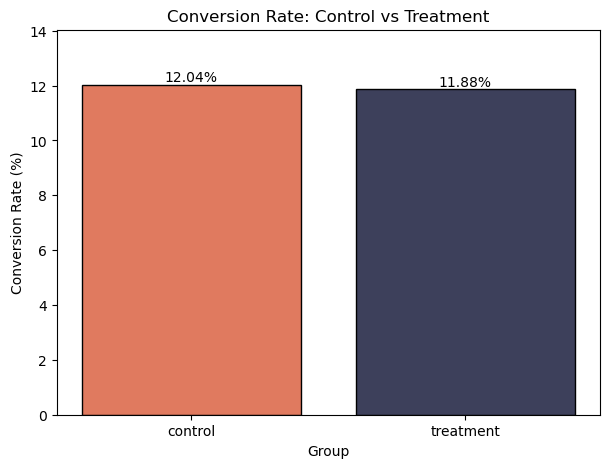

In [56]:
plt.figure(figsize=(7, 5))
colors=['#e07a5f','#3d405b']
plt.bar( conversion_rates.index,conversion_rates.values, color=colors,edgecolor='black')

plt.title("Conversion Rate: Control vs Treatment")
plt.xlabel("Group")
plt.ylabel("Conversion Rate (%)")

for i, value in enumerate(conversion_rates.values):
    plt.text(i,value + 0.1,f"{value:.2f}%",ha="center")

plt.ylim(0, max(conversion_rates.values) + 2)
plt.show()

# VIZUAL 2:

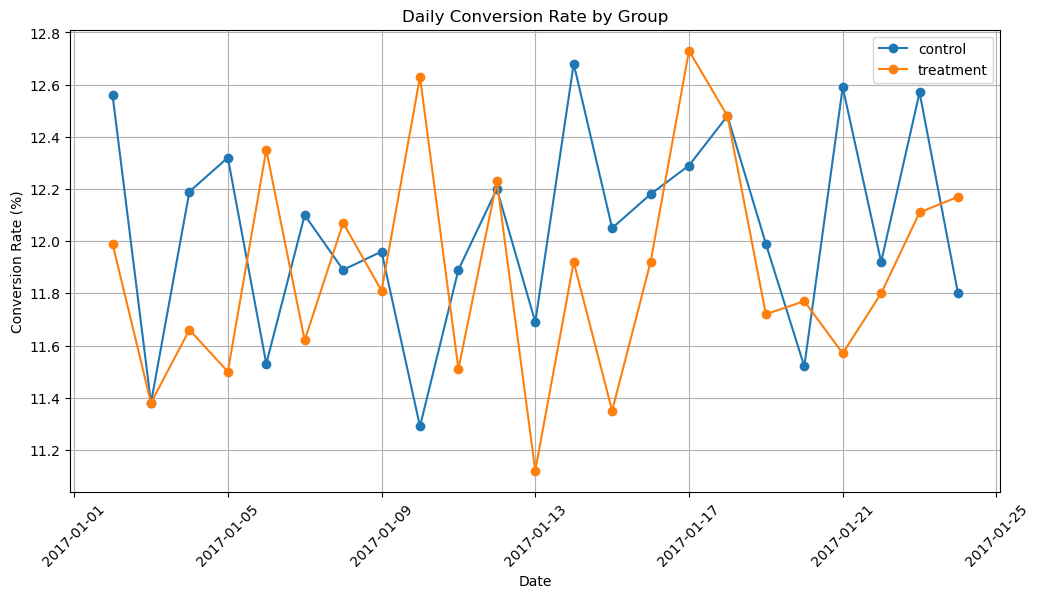

In [57]:
plt.figure(figsize=(12, 6))

for group in ["control", "treatment"]:
    
    data = daily_conversion[daily_conversion["group"] == group]
    
    plt.plot(
        data["date"],
        data["conversion_rate"],
        marker="o",
        label=group)

plt.title("Daily Conversion Rate by Group")
plt.xlabel("Date")
plt.ylabel("Conversion Rate (%)")

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

# VIZUAL 3:

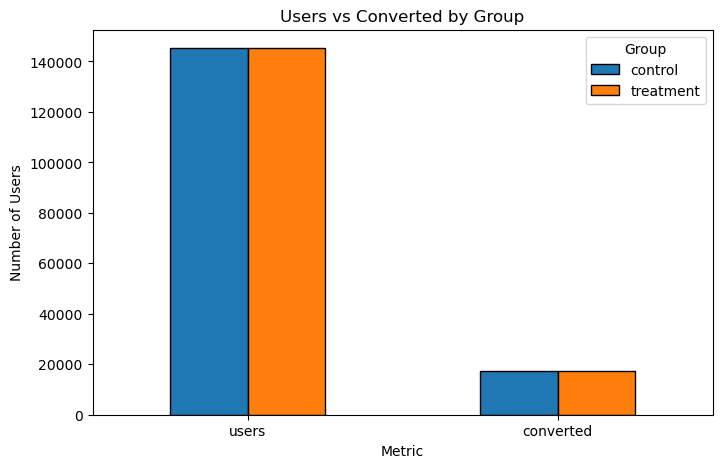

In [61]:
funnel = df_clean.groupby("group").agg(
    users=("user_id", "count"),
    converted=("converted", "sum"))

funnel.T.plot(kind="bar",figsize=(8, 5),edgecolor='black')

plt.title("Users vs Converted by Group")
plt.xlabel("Metric")
plt.ylabel("Number of Users")
plt.xticks(rotation=0)
plt.legend(title="Group")
plt.show()

# BONUS 1 :

In [62]:
df_clean["hour"] = df_clean["timestamp"].dt.hour

In [65]:
hourly_conversion = (df_clean.groupby(["hour", "group"])["converted"].mean().reset_index())

In [69]:
hourly_conversion['converted']*=100

In [70]:
hourly_conversion

,hour,group,converted
0,0,control,12.038605
1,0,treatment,12.029324
2,1,control,11.609158
3,1,treatment,11.127646
4,2,control,11.329156
5,2,treatment,11.338661
6,3,control,11.491525
7,3,treatment,11.509404
8,4,control,12.078652
9,4,treatment,10.736454


In [72]:
hourly_conversion.pivot(
    index="hour",
    columns="group",
    values="converted")

group,control,treatment
hour,,
0,12.038605,12.029324
1,11.609158,11.127646
2,11.329156,11.338661
3,11.491525,11.509404
4,12.078652,10.736454
5,12.356792,11.823222
6,12.770885,11.491768
7,11.929308,11.586777
8,11.701434,11.993328


### Günün müxtəlif saatlarında nəticələr nəzərə çarpacaq dərəcədə dəyişmir. Ona görədə vaxt amili nəticələrə təsir göstərmir.

# BONUS 2:

In [73]:
conversion_rates = df_clean.groupby("group")["converted"].mean()
control_rate = conversion_rates["control"]
treatment_rate = conversion_rates["treatment"]

extra_conversions = (treatment_rate - control_rate) * 1_000_000

In [76]:
print(extra_conversions.round(2))

-1579.06


In [80]:
if extra_conversions > 0:
    print(f"Treatment 1M istifadəçiyə {extra_conversions:,.0f} convertion bilər")
else:
    print(f"Treatment 1M istifadəçiyə {abs(extra_conversions):,.0f} convertion itirə bilər")

Treatment 1M istifadəçiyə 1,579 convertion itirə bilər
